In [3]:
# Standard library
from pathlib import Path
from collections import Counter

# Data analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image

# Reproducibility
np.random.seed(42)

print("Environment initialized")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")
print(f"Pillow : {Image.__version__}")

Environment initialized
NumPy  : 2.4.6
Pandas : 3.0.3
Pillow : 12.2.0


In [7]:
# Dataset paths

datasetRoot = Path("../dataset")


dataSplits = {
    "train": datasetRoot / "train",
    "val": datasetRoot / "val",
    "test": datasetRoot / "test"
}


for splitName, splitPath in dataSplits.items():

    assert splitPath.exists(), (
        f"{splitName} folder not found at {splitPath}"
    )


classNames = sorted(
    folder.name
    for folder in dataSplits["train"].iterdir()
    if folder.is_dir()
)


numClasses = len(classNames)


print(f"Classes ({numClasses}):")

classNames

Classes (8):


['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']

In [9]:
# Count images across dataset splits

def countImages(splitPath, classNames):

    counts = {}

    for className in classNames:

        classPath = splitPath / className

        imageFiles = [
            file
            for file in classPath.iterdir()
            if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ]

        counts[className] = len(imageFiles)

    return counts

# Count images for each split

trainCounts = countImages(
    dataSplits["train"],
    classNames )

valCounts = countImages(
    dataSplits["val"],
    classNames )

testCounts = countImages(
    dataSplits["test"],
    classNames )

# Create dataset summary table

datasetDistribution = pd.DataFrame(
    {
        "class": classNames,
        "train": list(trainCounts.values()),
        "val": list(valCounts.values()),
        "test": list(testCounts.values())
    }
)

datasetDistribution["total"] = (
    datasetDistribution["train"]
    + datasetDistribution["val"]
    + datasetDistribution["test"]
)

totalImages = datasetDistribution["total"].sum()

print(
    f"Total images: {totalImages}"
)


datasetDistribution

Total images: 24000


,class,train,val,test,total
0,AMD,2300,350,350,3000
1,CNV,2300,350,350,3000
2,CSR,2300,350,350,3000
3,DME,2300,350,350,3000
4,DR,2300,350,350,3000
5,DRUSEN,2300,350,350,3000
6,MH,2300,350,350,3000
7,NORMAL,2300,350,350,3000


In [10]:
# Analyze image dimensions

SAMPLE_PER_CLASS = 50

imageMetadata = []


for className in classNames:

    classPath = (
        dataSplits["train"] / className
    )


    imagePaths = list(
        classPath.glob("*")
    )


    for imagePath in imagePaths[:SAMPLE_PER_CLASS]:

        try:

            image = Image.open(
                imagePath
            )


            imageMetadata.append(
                {
                    "class": className,
                    "width": image.width,
                    "height": image.height,
                    "mode": image.mode
                }
            )


        except Exception as error:

            print(
                f"Skipped {imagePath.name}: {error}"
            )


imageMetadata = pd.DataFrame(
    imageMetadata
)


imageMetadata.describe()

uniqueSizes = (
    imageMetadata[
        ["width", "height"]
    ]
    .drop_duplicates()
)


print(
    f"Unique sizes: {len(uniqueSizes)}"
)


uniqueSizes.head()

Unique sizes: 7


,width,height
0,1000,512
50,512,496
51,1536,496
53,768,496
100,750,500


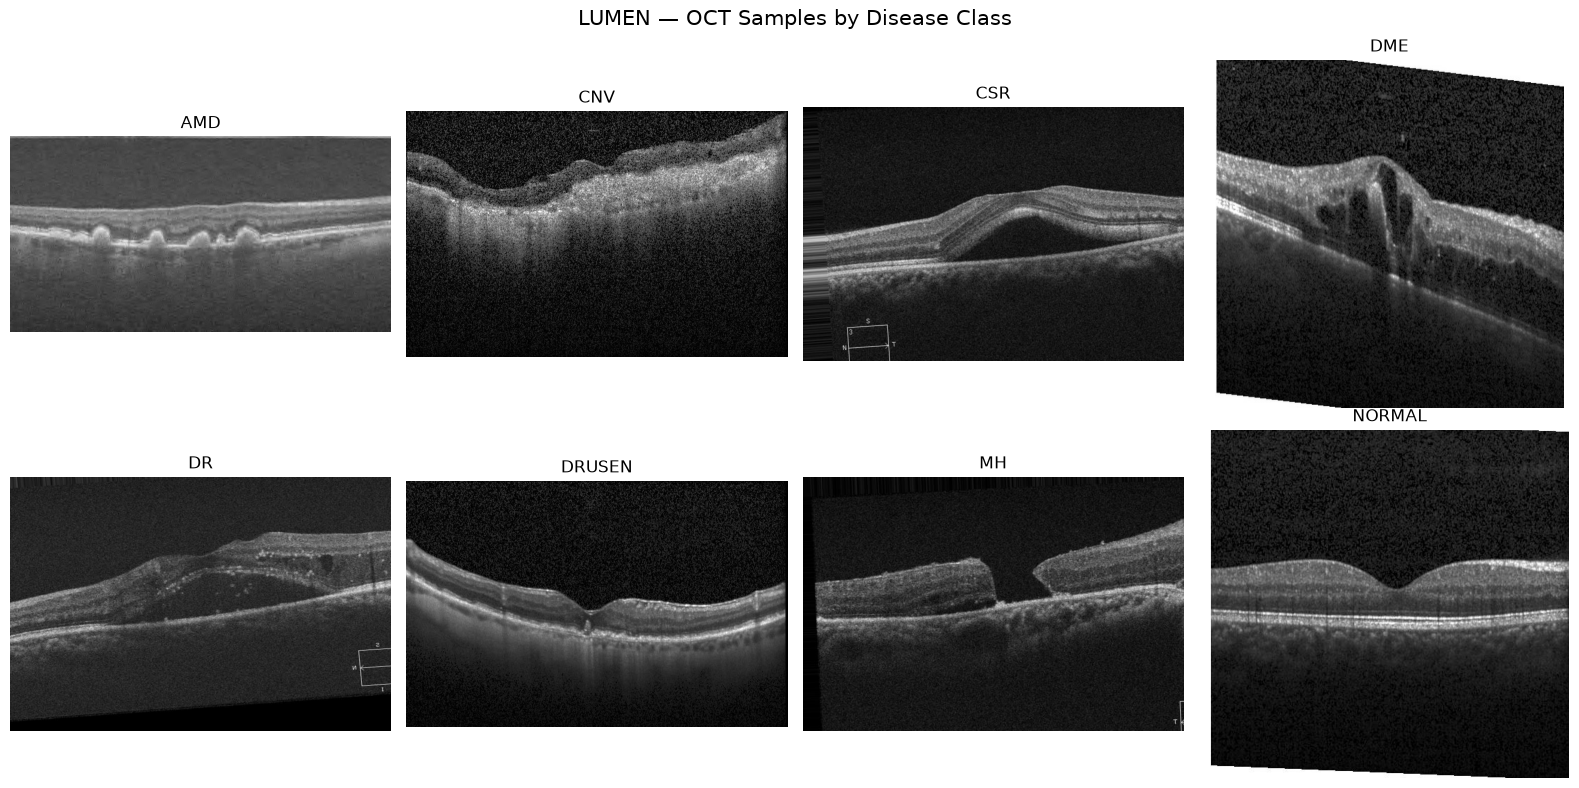

In [11]:
# Visualize sample OCT images

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)


axes = axes.flatten()


for index, className in enumerate(classNames):

    classPath = (
        dataSplits["train"] / className
    )


    imagePaths = list(
        classPath.glob("*")
    )


    imagePath = np.random.choice(
        imagePaths
    )


    image = Image.open(
        imagePath
    ).convert("RGB")


    axes[index].imshow(
        image
    )


    axes[index].set_title(
        className,
        fontsize=12
    )


    axes[index].set_xlabel(
        f"{image.width} × {image.height}"
    )


    axes[index].axis(
        "off"
    )


plt.suptitle(
    "LUMEN — OCT Samples by Disease Class",
    fontsize=15
)


plt.tight_layout()


plt.savefig(
    "../results/sampleImages.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [14]:
# Analyze class imbalance

totalTrainImages = (
    datasetDistribution["train"].sum()
)


maxClass = (
    datasetDistribution
    .sort_values("train", ascending=False)
    .iloc[0]
)


minClass = (
    datasetDistribution
    .sort_values("train")
    .iloc[0]
)


imbalanceRatio = (
    maxClass["train"]
    / minClass["train"]
)


datasetDistribution["trainPercentage"] = (
    datasetDistribution["train"]
    / totalTrainImages
    * 100
)


print(
    f"Maximum class : {maxClass['class']} ({maxClass['train']})"
)


print(
    f"Minimum class : {minClass['class']} ({minClass['train']})"
)


print(
    f"Imbalance ratio: {imbalanceRatio:.2f}x"
)


if imbalanceRatio > 3:

    lossFunction = "Weighted CrossEntropyLoss"

else:

    lossFunction = "Standard CrossEntropyLoss"


print(
    f"Recommended loss: {lossFunction}"
)


datasetDistribution



Maximum class : AMD (2300)
Minimum class : AMD (2300)
Imbalance ratio: 1.00x
Recommended loss: Standard CrossEntropyLoss


,class,train,val,test,total,trainPercentage
0,AMD,2300,350,350,3000,12.5
1,CNV,2300,350,350,3000,12.5
2,CSR,2300,350,350,3000,12.5
3,DME,2300,350,350,3000,12.5
4,DR,2300,350,350,3000,12.5
5,DRUSEN,2300,350,350,3000,12.5
6,MH,2300,350,350,3000,12.5
7,NORMAL,2300,350,350,3000,12.5


In [17]:
# Dataset exploration summary

edaSummary = {
    "classes": numClasses,
    "totalImages": totalImages,

    "trainImages": trainCounts,
    "validationImages": valCounts,
    "testImages": testCounts,

    "imageSize": "224 x 224",
    "channels": "RGB",

    "imbalanceRatio": round(
        imbalanceRatio,
        2
    ),

    "lossFunction": lossFunction,

    "normalization": "ImageNet mean/std"
}


for key, value in edaSummary.items():

    print(
        f"{key}: {value}"
    )


    summaryPath = (
    Path("../results")
    / "edaSummary.txt"
)


with open(summaryPath, "w") as file:

    for key, value in edaSummary.items():

        file.write(
            f"{key}: {value}\n"
        )

classes: 8
totalImages: 24000
trainImages: {'AMD': 2300, 'CNV': 2300, 'CSR': 2300, 'DME': 2300, 'DR': 2300, 'DRUSEN': 2300, 'MH': 2300, 'NORMAL': 2300}
validationImages: {'AMD': 350, 'CNV': 350, 'CSR': 350, 'DME': 350, 'DR': 350, 'DRUSEN': 350, 'MH': 350, 'NORMAL': 350}
testImages: {'AMD': 350, 'CNV': 350, 'CSR': 350, 'DME': 350, 'DR': 350, 'DRUSEN': 350, 'MH': 350, 'NORMAL': 350}
imageSize: 224 x 224
channels: RGB
imbalanceRatio: 1.0
lossFunction: Standard CrossEntropyLoss
normalization: ImageNet mean/std
